In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

#### Loading Data-Table

In [31]:
tab2 = Table.read("C:/Users/Ruben/Desktop/All_candidates.vot")

In [32]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

dist_pc2 = r_from_plx(np.array(tab2["parallax"])) # in pc
r_pc2 = dist_pc2 * np.cos(np.array(tab2["b"])*deg2rad) # in pc
g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag
apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5

o1 = 2.8*bp_rp2+1.0

u1 = 2.8*bp_rp2+3.4
u4 = 5.0*bp_rp2+4.0

left2 = (8 * (-1/3) * bp_rp2 + 9.2)
right2 = (8 * (-1/3) * bp_rp2 + 12.2)
middle2 = (8 * (-1/3) * bp_rp2 + 10.7)

In [33]:
tab = tab2[(r_pc2 < 200.)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right2)&(absolute_magnitude2>=left2)]

### z dependence of stars with inaccurate parallaxe measurment

Sterne ohne Parallaxe oder Unsicherheit:  0


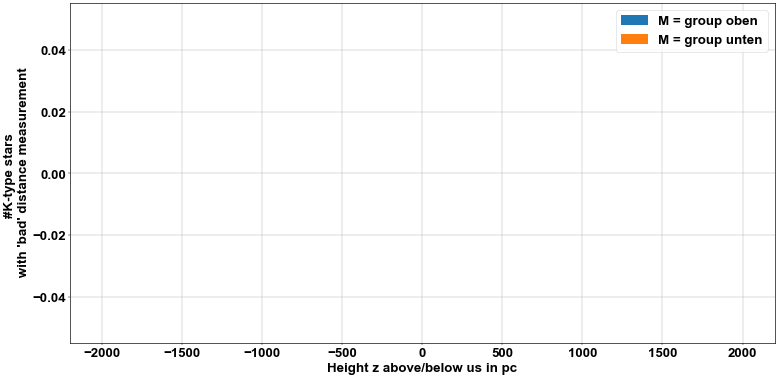

Requirement: parallax/standarterror(parallax) is larger than 0. This ensures useful parallax measurment. Removes an additional 0.00e+00 sources
We are left with 4.70e+05 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 1.65e+03 sources
We are left with 4.69e+05 sources


In [34]:
dist_pc = r_from_plx(np.array(tab["parallax"])) # in pc
apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5
bp_rp = np.array(tab["bp_rp"]) # in mag

left = (8 * (-1/3) * bp_rp + 9.2)
right = (8 * (-1/3) * bp_rp + 12.2)
middle = (8 * (-1/3) * bp_rp + 10.7)

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
print("Sterne ohne Parallaxe oder Unsicherheit: ", np.sum(np.isnan(parallax_over_error)))
min = 0
mask0 = parallax_over_error > min
group1 = (absolute_magnitude[~mask0] >= left[~mask0]) & (absolute_magnitude[~mask0] < middle[~mask0])
group2 = (absolute_magnitude[~mask0] >= middle[~mask0]) & (absolute_magnitude[~mask0] <= right[~mask0])
z_out = (dist_pc*np.sin(tab["b"]*deg2rad))[~mask0]
absolute_magnitude_out = absolute_magnitude[~mask0]

fig = plt.figure(figsize=(20,10))
plt.hist([z_out[group1], z_out[group2]], bins=44, stacked=True, range=(-2000, 2000), label=["M = group oben", "M = group unten"])
plt.xlabel("Height z above/below us in pc")
plt.ylabel("#K-type stars \n with 'bad' distance measurement")
plt.grid()
plt.tight_layout()
plt.legend()
# plt.savefig("Plots/Height_distribution_bad_distance_measurement.png")
fig.set_dpi(40)
plt.show()

print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(min, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

# Cylinder symmetrical around galactic plane
height = 1800. # pc
mask1 = (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)<height-14.5) & (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)>-height-14.5)
print("Requirement: Inside the cylinder of 2 * {} pc hight (centered at galactic plane!). Removes an additional {:.2e} sources".format(height, np.nansum(~mask1)))
print("We are left with {:.2e} sources".format(np.nansum(mask1)))

#### Selecting a subsample

In [35]:
def filtration(left, right):
# make this smaller for better volume completeness (default 8.0)

    # Absolute magnitude limits
    mask2 = (absolute_magnitude[mask0][mask1]>=left[mask0][mask1]) & (absolute_magnitude[mask0][mask1]<=right[mask0][mask1])
    print("Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional {:.2e} sources".format(np.nansum(~mask2)))
    print("We are left with {:.2e} sources".format(np.nansum(mask2)))
    tab_filtered = tab[mask0][mask1][mask2]

    return tab_filtered

In [36]:
# Load into separate numpy arrays
def arrays(tab_filtered):
    np_arr = np.array(tab_filtered)

    l_np = np_arr["l"]
    b_np = np_arr["b"]
    ra_np = np_arr["ra"]
    ra_error_np = np_arr["ra_error"]
    dec_np = np_arr["dec"]
    dec_error_np = np_arr["dec_error"]
    parallax_np = np_arr["parallax"]
    parallax_error_np = np_arr["parallax_error"]
    pmra_np = np_arr["pmra"]
    pmra_error_np = np_arr["pmra_error"]
    pmdec_np = np_arr["pmdec"]
    pmdec_error_np = np_arr["pmdec_error"]
    phot_g_mean_mag_np = np_arr["phot_g_mean_mag"]
    teff_gspphot_np = np_arr["teff_gspphot"]
    bp_rp_np = np_arr["bp_rp"]
    radial_velocity_np = np_arr["radial_velocity"]
    radial_velocity_error_np = np_arr["radial_velocity_error"]

    del np_arr

    return l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np

# Vertical Distribution and Velocity Dispersion

In [37]:
###  Functions for computing the vertical velocity
def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    
    return v_z

# Velocity Dispersion

Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 0.00e+00 sources
We are left with 4.69e+05 sources
Kleinste Parallax/Error:  1.587562030760336
Mean vertical velocity =  -7.936656280567911 km/s
Mean squared deviation =  465.35883328497573
Std. dev. of squared deviation 1247.6533297874325


C:\Users\Ruben\AppData\Local\Temp\ipykernel_36116\2342437199.py:3: RuntimeWarning: invalid value encountered in log
  mu = np.log(mean)-0.5*np.log((std/mean)**2+1)


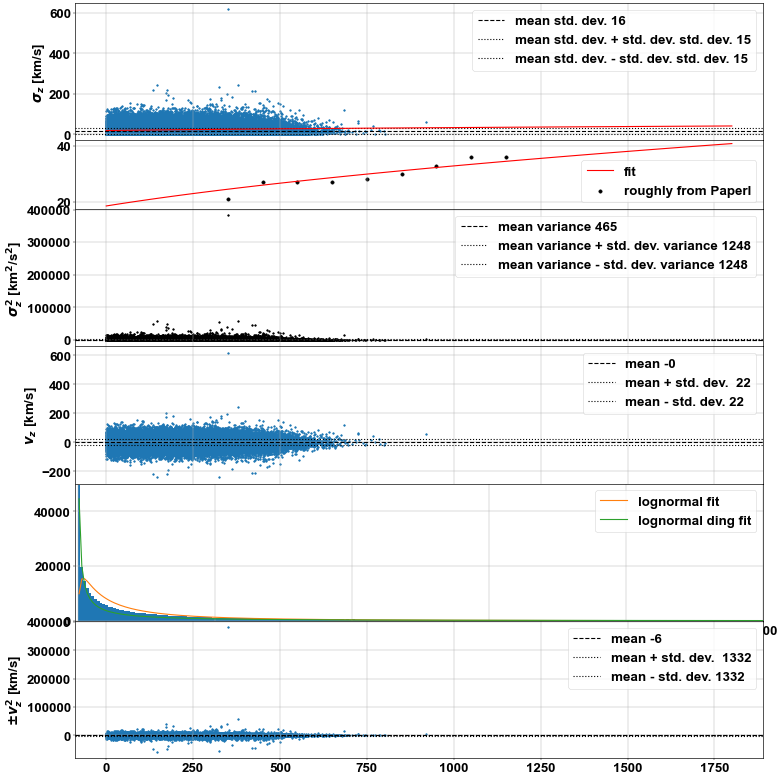

Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 2.32e+05 sources
We are left with 2.37e+05 sources
Kleinste Parallax/Error:  2.285805018713378
Mean vertical velocity =  -7.85289878972155 km/s
Mean squared deviation =  459.67735806014343
Std. dev. of squared deviation 1430.090363207993


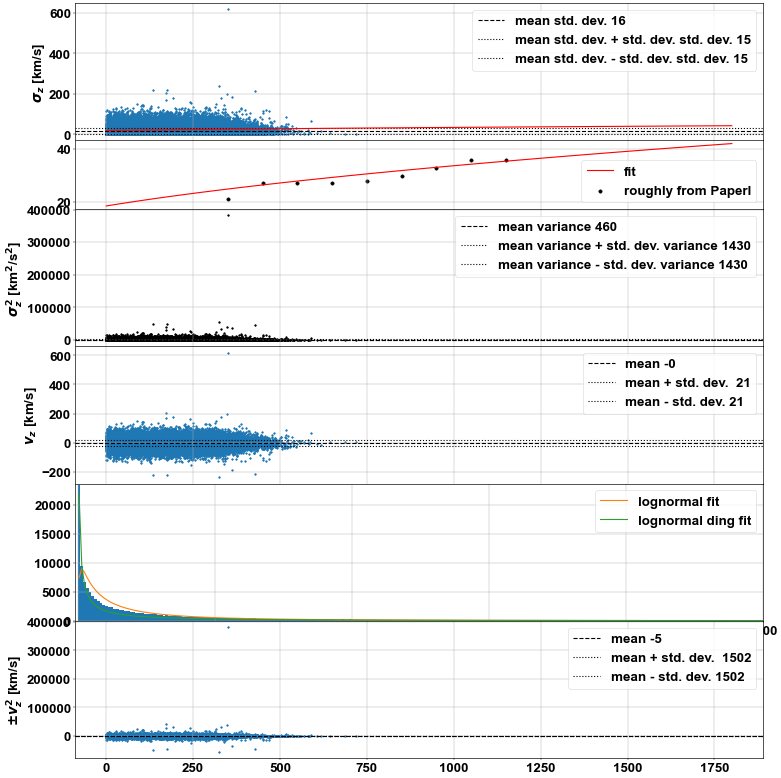

Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 2.37e+05 sources
We are left with 2.32e+05 sources
Kleinste Parallax/Error:  1.587562030760336
Mean vertical velocity =  -8.010389056651459 km/s
Mean squared deviation =  470.34869542234105
Std. dev. of squared deviation 1061.145323916559


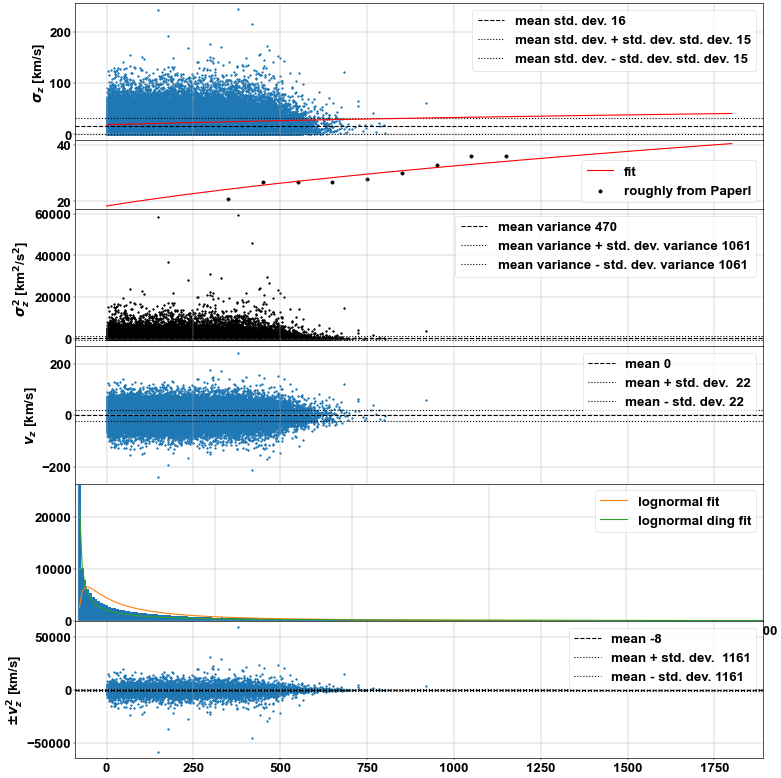

In [38]:
def params(mean, std):
    'takes arithmetic params and returns classical params'
    mu = np.log(mean)-0.5*np.log((std/mean)**2+1)
    sigma = np.sqrt(np.log((std/mean)**2+1))
    return mu, sigma

def poly_fit(left, right, label):
    tab_filtered = filtration(left, right)
    
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz) 
    print("Kleinste Parallax/Error: ", np.min((parallax_np/parallax_error_np)[hasv]))
    vmean = np.mean(vz[hasv])
    print("Mean vertical velocity = ", vmean, "km/s")
    v2 = (vz[hasv]-vmean)**2
    print("Mean squared deviation = ", np.mean(v2))
    print("Std. dev. of squared deviation", np.sqrt(np.var(v2)))

    # Lets fit a simple curve
    POLYNOME_ORDER = 1
    v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
    zs = np.linspace(0, 1800, 100)
    sigmas = np.sqrt(v2_fit(zs))

    z_vel = np.array([350, 450, 550, 650, 750, 850, 950, 1050, 1150])
    s_vel = np.array([21., 27., 27., 27., 28., 30., 33., 36., 36.])

    fig, ax = plt.subplots(6,1, figsize=(20,20), gridspec_kw={'height_ratios': [2,1,2,2,2,2]})
    ax[0].scatter(np.abs(z_np)[hasv], np.sqrt(v2), marker='.')
    ax[0].axhline(np.mean(np.sqrt(v2)), color='black', ls='--', label='mean std. dev. {:.0f}'.format(np.mean(np.sqrt(v2))))
    ax[0].axhline(np.mean(np.sqrt(v2))+np.sqrt(np.var(np.sqrt(v2))), color='black', ls=':', label='mean std. dev. + std. dev. std. dev. {:.0f}'.format(np.sqrt(np.var(np.sqrt(v2)))))
    ax[0].axhline(np.mean(np.sqrt(v2))-np.sqrt(np.var(np.sqrt(v2))), color='black', ls=':', label='mean std. dev. - std. dev. std. dev. {:.0f}'.format(np.sqrt(np.var(np.sqrt(v2)))))
    ax[0].plot(zs, sigmas, color='r')
    ax[0].set_ylabel(r"$\sigma_z$ [km/s]")
    ax[0].grid()
    ax[0].legend()
    ax[1].plot(zs, sigmas, color='r', label='fit')
    ax[1].scatter(z_vel, s_vel, color='black', label='roughly from PaperI')
    ax[1].grid()
    ax[1].legend()
    ax[1].sharex(ax[0])
    ax[2].axhline(np.mean(v2), color='black', ls='--', label='mean variance {:.0f}'.format(np.mean(v2)))
    ax[2].axhline(np.mean(v2)+np.sqrt(np.var(v2)), color='black', ls=':', label='mean variance + std. dev. variance {:.0f}'.format(np.sqrt(np.var(v2))))
    ax[2].axhline(np.mean(v2)-np.sqrt(np.var(v2)), color='black', ls=':', label='mean variance - std. dev. variance {:.0f}'.format(np.sqrt(np.var(v2))))
    ax[2].scatter(np.abs(z_np)[hasv], v2, marker='.', color='black')
    ax[2].set_ylabel(r"$\sigma_z^2$ [km$^2$/s$^2$]")
    ax[2].grid()
    ax[2].legend()
    ax[2].sharex(ax[0])
    ax[3].scatter(np.abs(z_np)[hasv], vz[hasv]-vmean, marker='.')
    ax[3].axhline(np.mean(vz[hasv]-vmean), color='black', ls='--', label='mean {:.0f}'.format(np.mean(vz[hasv]-vmean)))
    ax[3].axhline(np.mean(vz[hasv]-vmean)+np.sqrt(np.var(vz[hasv]-vmean)), color='black', ls=':', label='mean + std. dev.  {:.0f}'.format(np.sqrt(np.var(vz[hasv]-vmean))))
    ax[3].axhline(np.mean(vz[hasv]-vmean)-np.sqrt(np.var(vz[hasv]-vmean)), color='black', ls=':', label='mean - std. dev. {:.0f}'.format(np.sqrt(np.var(vz[hasv]-vmean))))
    ax[3].set_ylabel(r"$v_z$ [km/s]")
    ax[3].grid()
    ax[3].legend()
    ax[3].sharex(ax[0])
    ding = np.append(((vz[hasv]-vmean)[np.where((vz[hasv]-vmean)>=0)])**2, -((vz[hasv]-vmean)[np.where((vz[hasv]-vmean)<0)])**2)
    z_ding = np.append(np.abs(z_np)[hasv][np.where((vz[hasv]-vmean)>=0)], np.abs(z_np)[hasv][np.where((vz[hasv]-vmean)<0)])
    ax[5].scatter(z_ding, ding, marker='.')
    ax[5].axhline(np.mean(ding), color='black', ls='--', label='mean {:.0f}'.format(np.mean(ding)))
    ax[5].axhline(np.mean(ding)+np.sqrt(np.var(ding)), color='black', ls=':', label='mean + std. dev.  {:.0f}'.format(np.sqrt(np.var(ding))))
    ax[5].axhline(np.mean(ding)-np.sqrt(np.var(ding)), color='black', ls=':', label='mean - std. dev. {:.0f}'.format(np.sqrt(np.var(ding))))
    ax[5].set_ylabel(r"$\pm v_z^2$ [km/s]")
    ax[5].grid()
    ax[5].legend()
    ax[5].sharex(ax[0])
    n, bins, _ = ax[4].hist(v2, bins=10000, range=(0, 100000))
    s = np.sum(n)
    z = (bins[:-1] + bins[1:])/2
    mu, sigma = params(np.mean(v2), np.sqrt(np.var(v2)))
    mu_ding, sigma_ding = params(np.mean(ding), np.sqrt(np.var(ding)))
    lognormal = 1/(z*sigma*np.sqrt(2*np.pi))*np.exp(-(np.log(z)-mu)**2/(2*sigma**2))
    lognormal_ding = 1/(z*sigma_ding*np.sqrt(2*np.pi))*np.exp(-(np.log(z)-mu)**2/(2*sigma_ding**2))
    ax[4].plot(z, lognormal*s*10, label='lognormal fit')
    ax[4].plot(z, lognormal_ding*s*10, label='lognormal ding fit')
    ax[4].grid()
    ax[4].set_ylim(0, 1.01*max(n))
    ax[4].set_xlim(-10, 2500)
    ax[4].legend()
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.0)
    fig.set_dpi(40)
    plt.show()

    df = pd.DataFrame({'z': z_np[hasv], 'v2': v2})

    # Create a text file
    df.to_csv(f'v2_{label}.txt', index=False, sep=',', header=True)
    np.savetxt(f'poly_{label}.txt', [*np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER), vmean, np.mean(v2), np.sqrt(np.var(v2))], fmt='%f')

poly_fit(left, right, 'full_o1u1')
poly_fit(middle, right, 'lower_o1u1')
poly_fit(left, middle, 'upper_o1u1')

Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 0.00e+00 sources
We are left with 4.69e+05 sources
Geschwindigkeitsdaten von  322389  Sternen.
Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 2.37e+05 sources
We are left with 2.32e+05 sources
Geschwindigkeitsdaten von  171455  Sternen.
Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 2.32e+05 sources
We are left with 2.37e+05 sources
Geschwindigkeitsdaten von  150934  Sternen.


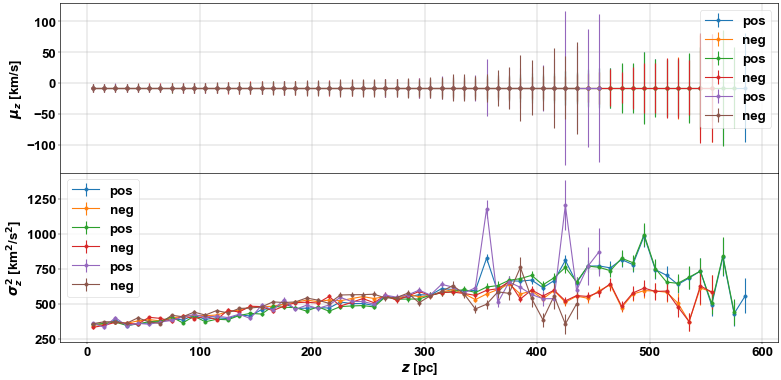

' bei kleinen Werten Chi^2 Verteilung --> dort ist Gauss unsinnig'

In [39]:
def vel_disp2(left, right, label, n_bins):

    tab_filtered = filtration(left, right)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz)
    vz = vz[hasv]
    z_np = z_np[hasv]
    vz_mean = np.genfromtxt(f'poly_full_o1u1.txt')[2]
    print('Geschwindigkeitsdaten von ', len(z_np), ' Sternen.')

    bins = np.linspace(-1800, 1800, n_bins+1)
    vz_vars = np.array([])
    evz_means = np.array([])
    evz_vars = np.array([])
    for i in range(len(bins)-1):
        mask = (z_np >= bins[i]) & (z_np < bins[i+1])
        if sum(mask) >= 40:
            vz_vars = np.append(vz_vars, np.sum((vz[mask]-vz_mean)**2/(sum(mask)))) #nicht so richtig unbiased weil -1 fehlt
            evz_means = np.append(evz_means, vz_vars[-1]/np.sqrt(np.sum(mask))) #ergibt das Sinn? Var = Var(z) aber Mean = const(z)
            evz_vars = np.append(evz_vars, vz_vars[-1]*np.sqrt(2/(np.sum(mask)-1)))
        else:
            vz_vars = np.append(vz_vars, np.nan)
            evz_means = np.append(evz_means, np.nan)
            evz_vars = np.append(evz_vars, np.nan)
    #     if i == 230:
    #         print(vz[mask])
    # print(vz_vars[230])
    # print(evz_means[230])
    # print(evz_vars[230])
    
    z = (bins[1:]+bins[:-1])/2
    i = np.isnan(vz_vars)

    return vz_mean, vz_vars[~i], evz_means[~i], evz_vars[~i], z[~i]


fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True)
for am, n_bin in zip([[left,right, 'full_o1u1'], [left, middle, 'upper_o1u1'], [middle, right, 'lower_o1u1']], [360, 360, 360]):
    vz_mean, vz_vars, evz_means, evz_vars, z= vel_disp2(*am, n_bin)
    pos = np.where(z>=0)
    neg = np.where(z<0)
    ax[0].errorbar(z[pos], vz_mean*np.ones(len(z[pos])), yerr=evz_means[pos], marker='o',label=f"pos")
    ax[0].errorbar(abs(z[neg]), vz_mean*np.ones(len(z[neg])), yerr=evz_means[neg], marker='o',label=f"neg")
    ax[1].errorbar(z[pos], vz_vars[pos], yerr=evz_vars[pos], marker='o', label=f"pos")
    ax[1].errorbar(abs(z[neg]), vz_vars[neg], yerr=evz_vars[neg], marker='o', label=f"neg")
    data = {
        'z': z,
        'vz_mean': vz_mean,
        'vz_vars': vz_vars,
        'evz_means': evz_means,
        'evz_vars': evz_vars
    }
    df = pd.DataFrame(data)
    df.to_csv(rf'v2_bin_{am[2]}.txt', index=False, sep=',', header=True)
ax[0].set_xlabel(r"$z$ [pc]")
ax[0].set_ylabel(r"$\mu_z$ [km/s]")
ax[0].grid()
ax[0].legend()
ax[1].set_xlabel(r"$z$ [pc]")
ax[1].set_ylabel(r"$\sigma_z^2$ [km$^2$/s$^2$]")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
# plt.savefig("Plots/Vertical_velocity_dispersion_comparison.png")
fig.set_dpi(40)
plt.show()

''' sinnvoll ???'''
''' Nein wenig Werte --> Students-t-Approximation'''
''' Nein Student-t nur für Mittelwert '''
''' bei kleinen Werten Chi^2 Verteilung --> dort ist Gauss unsinnig'''


Requirement: Absolute magnitude between left and right border function (gelb). Removes an additional 0.00e+00 sources
We are left with 4.69e+05 sources
Kleinste Parallax/Error:  0.7741436330961291


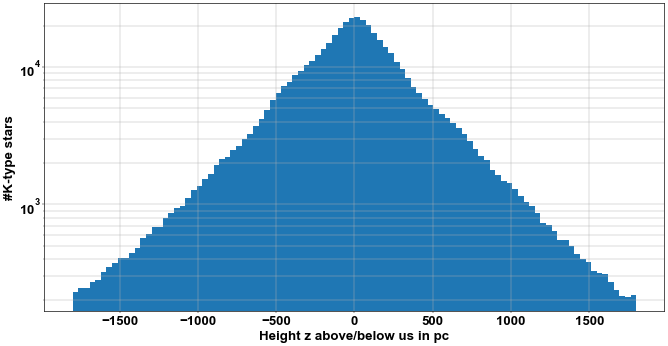

(3000, 100)
(100,)


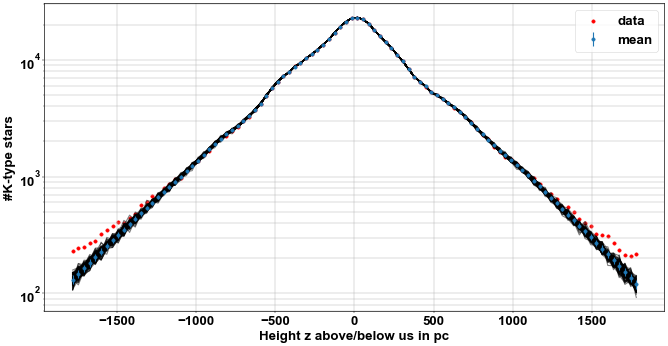

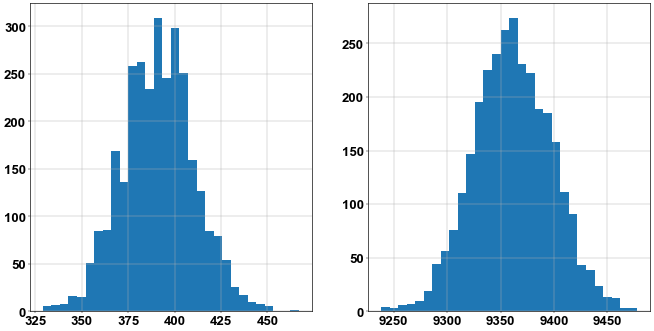

In [40]:
import jax.lax as lax
import jax.random as rand
import jax.numpy as jnp

def params(mean, std):
    'takes arithmetic params and returns classical params'
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    return mu, sigma

def sample(parallax, parallax_error, n, seed = 42):
    key = rand.PRNGKey(seed)
    key, subkey = rand.split(key)
    mu, sigma = params(parallax, parallax_error)
    standard_samp = rand.normal(subkey, shape=(n, len(parallax)))
    normal_samp = mu[jnp.newaxis,:] + standard_samp*sigma[jnp.newaxis, :]
    lognormal_samp = jnp.exp(normal_samp)
    return lognormal_samp


def Verarbeitung(left, right, label, n_bin, range, Plot):
    # Histogram in z
    tab_filtered = filtration(left, right)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    print("Kleinste Parallax/Error: ", np.min((parallax_np/parallax_error_np)))
    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    fig = plt.figure(figsize=(20,10))
    n, bins, _ = plt.hist(z_np, bins=n_bin, range=(-range, range))
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.grid(which='both')
    fig.set_dpi(40)
    if Plot:
        plt.show()
    else:
        plt.close()
    n_samp = 3000
    samples = sample(parallax_np, parallax_error_np, n_samp)
    fig = plt.figure(figsize=(20,10))
    r_ = r_from_plx(samples)
    z_ = r_ * jnp.sin(b_np[jnp.newaxis,:]*deg2rad) + 14.5
    bins_, n_ = lax.scan(lambda bins, z: jnp.histogram(z, bins=n_bin, range=(-range, range))[::-1], bins, z_)
    print(n_.shape)
    for ns in n_[::int(n_samp/100)]:
        plt.plot((bins_[:-1]+bins_[1:])/2, ns, color='black', alpha=0.5)
    n_mean = jnp.mean(n_, axis=0)
    n_std = jnp.std(n_, axis=0, ddof=1)
    print(n_mean.shape)
    plt.errorbar((bins_[:-1]+bins_[1:])/2, n_mean, yerr=n_std, fmt='o', label='mean')
    plt.scatter((bins[:-1]+bins[1:])/2, n, color='red', label='data')
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.legend()
    plt.grid(which='both')
    fig.set_dpi(40)
    if Plot:
        plt.show()
    else:
        plt.close()

    fig, ax = plt.subplots(1,2, figsize=(20,10))
    ax[0].hist(n_[:, 10], bins=30)
    ax[0].grid(which='both')
    ax[1].hist(n_[:, int(n_bin/2-10)], bins=30)
    ax[1].grid(which='both')
    fig.set_dpi(40)
    if Plot:
        plt.show()
    else:
        plt.close()

    # Create a text file
    # np.savetxt(f'n_{label}.txt', n, fmt='%i')
    # np.savetxt(f'bins_{label}.txt', bins, fmt='%f')

Verarbeitung(left, right, 'full_o1u1', 100, 1800, True)
# Verarbeitung(left, middle, 'upper_o1u1', 100, 1800, True)
# Verarbeitung(middle, right, 'lower_o1u1', 100, 1800, True)